In [1]:

import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import xml.etree.ElementTree as ET
import mne
from tensorflow.keras import layers, models, callbacks, optimizers
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight


In [2]:

# ── Working Directory ──────────────────────────────────────────────
os.chdir(
    r"C:\Users\sara hamza\OneDrive - Helwan university"
    r"(Engineering (Helwan))\Desktop\4th year"
    r"\how chould a loss i had nothing\signals\so2"
)
print("Working directory:", os.getcwd())


Working directory: C:\Users\sara hamza\OneDrive - Helwan university(Engineering (Helwan))\Desktop\4th year\how chould a loss i had nothing\signals\so2


In [3]:

# ── Constants ──────────────────────────────────────────────────────
CHANNELS     = ['EOG-R']          # Single right EOG channel
OUT_CHANNELS = 1
TARGET_SFREQ = 100                # Resample to 100 Hz
EPOCH_SEC    = 30                 # Standard 30-second epochs
EPOCH_LENGTH = TARGET_SFREQ * EPOCH_SEC   # 3000 samples per epoch
CLASS_NAMES  = ['Wake', 'N1', 'N2', 'N3', 'REM']
STAGE_MAP    = {
    "Wake|0":           0,
    "Stage 1 sleep|1": 1,
    "Stage 2 sleep|2": 2,
    "Stage 3 sleep|3": 3,
    "REM sleep|5":     4,
}
STAGE_COLORS = {
    "Wake|0":           "red",
    "Stage 1 sleep|1": "lightblue",
    "Stage 2 sleep|2": "blue",
    "Stage 3 sleep|3": "darkblue",
    "REM sleep|5":     "green",
}

tf.keras.backend.clear_session()


In [4]:

# ══════════════════════════════════════════════════════════════════
# Building Blocks
# ══════════════════════════════════════════════════════════════════

def se_block(x, ratio=16):
    """Squeeze-and-Excitation: learns per-channel importance weights."""
    filters = x.shape[-1]
    se = layers.GlobalAveragePooling1D()(x)
    se = layers.Dense(max(filters // ratio, 8), activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    se = layers.Reshape((1, filters))(se)
    return layers.Multiply()([x, se])


def residual_conv_block(x, filters, kernel_size, strides=1):
    """Residual Conv block with SE attention and optional projection shortcut."""
    shortcut = x
    out = layers.Conv1D(filters, kernel_size, strides=strides,
                        padding='same', use_bias=False)(x)
    out = layers.BatchNormalization()(out)
    out = layers.Activation('relu')(out)
    out = layers.Conv1D(filters, kernel_size, strides=1,
                        padding='same', use_bias=False)(out)
    out = layers.BatchNormalization()(out)
    out = se_block(out)
    if strides != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, strides=strides,
                                 padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    out = layers.Add()([out, shortcut])
    return layers.Activation('relu')(out)


def temporal_attention_block(x, num_heads=4):
    """Transformer-style self-attention over time steps within each epoch."""
    embed_dim = x.shape[-1]
    attn = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads,
        dropout=0.1
    )(x, x)
    attn = layers.LayerNormalization(epsilon=1e-6)(layers.Add()([x, attn]))
    ff   = layers.Dense(embed_dim * 2, activation='gelu')(attn)
    ff   = layers.Dense(embed_dim)(ff)
    ff   = layers.Dropout(0.1)(ff)
    return layers.LayerNormalization(epsilon=1e-6)(layers.Add()([attn, ff]))



In [5]:

# ══════════════════════════════════════════════════════════════════
# Model Definition
# Architecture: Conv Stem → ResNet blocks → BiLSTM x2 → Attention
#               → GlobalAvg+Max Pooling → Dense Head → Softmax
# ══════════════════════════════════════════════════════════════════

def build_model(input_shape, num_classes=5):
    inputs = layers.Input(shape=input_shape)

    # Stem: kernel=25 captures slow EOG blink/saccade waveforms
    x = layers.Conv1D(64, kernel_size=25, strides=2,
                      padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(pool_size=2, strides=2)(x)

    # Stage 1: 128 filters
    x = residual_conv_block(x, filters=128, kernel_size=7)
    x = residual_conv_block(x, filters=128, kernel_size=7)
    x = layers.MaxPooling1D(pool_size=2, strides=2)(x)

    # Stage 2: 256 filters
    x = residual_conv_block(x, filters=256, kernel_size=5)
    x = residual_conv_block(x, filters=256, kernel_size=5)
    x = layers.MaxPooling1D(pool_size=2, strides=2)(x)
    x = layers.Dropout(0.3)(x)

    # BiLSTM: forward + backward temporal dependencies
    x = layers.Bidirectional(
        layers.LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.1)
    )(x)
    x = layers.Bidirectional(
        layers.LSTM(64,  return_sequences=True, dropout=0.2, recurrent_dropout=0.1)
    )(x)

    # Temporal self-attention
    x = temporal_attention_block(x, num_heads=4)

    # Dual pooling: combines average and max representations
    avg_pool = layers.GlobalAveragePooling1D()(x)
    max_pool = layers.GlobalMaxPooling1D()(x)
    x = layers.Concatenate()([avg_pool, max_pool])

    # Classification head
    x = layers.Dense(256, activation='gelu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='gelu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs, name="EOG_R_SleepStager")
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model



In [6]:

# ══════════════════════════════════════════════════════════════════
# process_single_record()
# Reads one EDF, extracts EOG-R, resamples, applies per-epoch
# z-score normalization, aligns with XML stage annotations.
# ══════════════════════════════════════════════════════════════════

def process_single_record(edf_path, xml_path):
    # Load and resample
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    raw.pick_channels(CHANNELS)
    raw.resample(TARGET_SFREQ, npad="auto", verbose=False)

    # Extract EOG-R
    eog_r = raw.get_data(picks='EOG-R')[0]     # shape: (n_samples,)
    data  = eog_r[:, np.newaxis]               # shape: (n_samples, 1)

    # Parse XML annotations
    root   = ET.parse(xml_path).getroot()
    events = [
        e for e in root.findall(".//ScoredEvent")
        if e.find("EventType").text == "Stages|Stages"
    ]

    # Build label array
    num_epochs = int(data.shape[0] / EPOCH_LENGTH)
    labels     = np.full(num_epochs, -1)
    for e in events:
        start = int(float(e.find("Start").text)    / EPOCH_SEC)
        n_ep  = int(float(e.find("Duration").text) / EPOCH_SEC)
        stage = e.find("EventConcept").text
        if stage in STAGE_MAP:
            labels[start : min(start + n_ep, num_epochs)] = STAGE_MAP[stage]

    # Reshape to (epochs, 3000, 1)
    data = data[:num_epochs * EPOCH_LENGTH]
    X    = data.reshape(num_epochs, EPOCH_LENGTH, OUT_CHANNELS)

    # Per-epoch z-score normalization (removes DC drift between subjects)
    mean = X.mean(axis=1, keepdims=True)
    std  = X.std(axis=1,  keepdims=True) + 1e-8
    X    = (X - mean) / std

    # Remove unlabeled epochs
    mask = labels != -1
    return X[mask], labels[mask]


print("✅ All imports, constants, and functions loaded successfully!")

✅ All imports, constants, and functions loaded successfully!


Extracting EDF parameters from Dataset/Signals/mesa-sleep-0010.edf...
Setting channel info structure...
Creating raw.info structure...


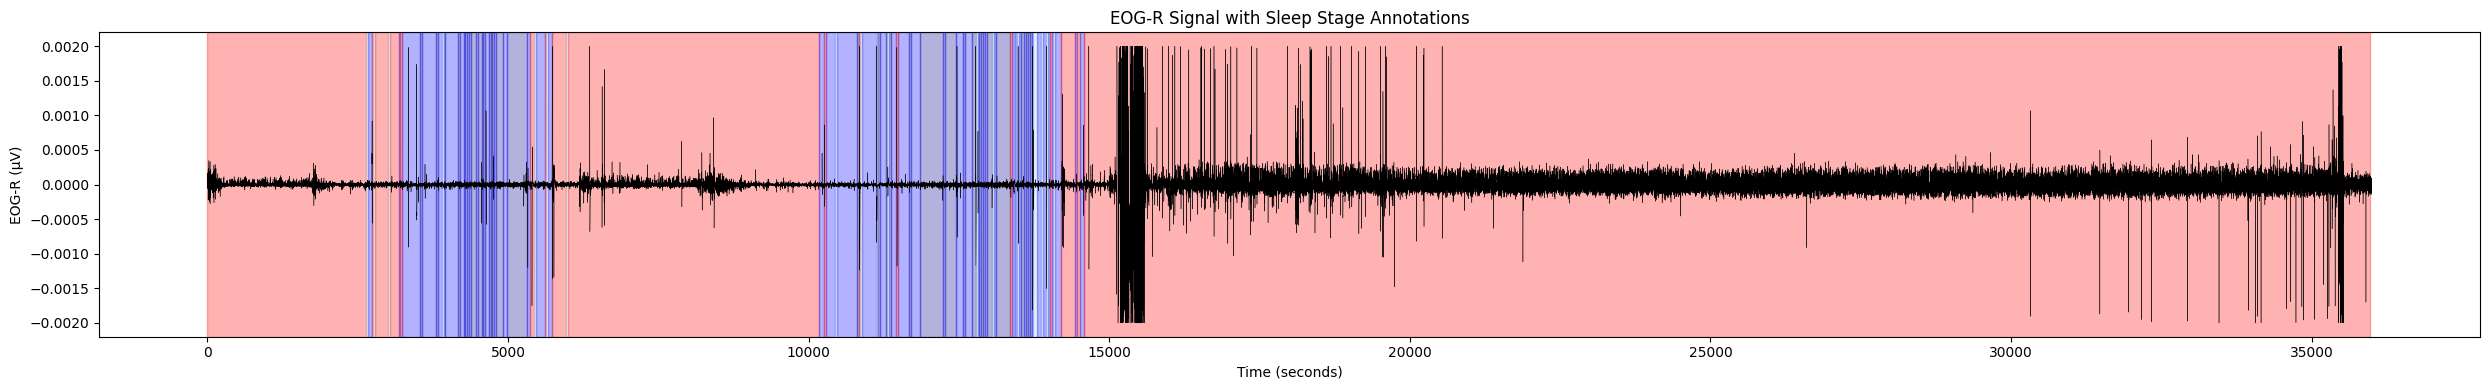

In [7]:
# Visualize EOG-R Signal with Sleep Stage Annotations

EDF_FILE = "Dataset/Signals/mesa-sleep-0010.edf"
XML_FILE = "Dataset/Annotations/mesa-sleep-0010-nsrr.xml"

# Load raw EDF (no preload needed for visualization)
raw   = mne.io.read_raw_edf(EDF_FILE, preload=False)
sfreq = raw.info['sfreq']

# Parse sleep stage events
tree   = ET.parse(XML_FILE)
events = [
    e for e in tree.getroot().findall(".//ScoredEvent")
    if e.find("EventType").text == "Stages|Stages"
]

# Downsample for fast plotting
STEP  = 200
eog_r = raw.get_data(picks='EOG-R')[0][::STEP]
times = np.arange(len(eog_r)) / (sfreq / STEP)

fig, ax = plt.subplots(figsize=(25, 4))
ax.plot(times, eog_r, color='black', linewidth=0.3)
ax.set_ylabel('EOG-R (µV)')
ax.set_title('EOG-R Signal with Sleep Stage Annotations')

# Overlay color-coded sleep stage spans
for e in events:
    start    = float(e.find("Start").text)
    duration = float(e.find("Duration").text)
    stage    = e.find("EventConcept").text
    ax.axvspan(start, start + duration,
               color=STAGE_COLORS.get(stage, "gray"), alpha=0.3)

ax.set_xlabel('Time (seconds)')
plt.tight_layout()
plt.show()

In [8]:
#Train / Validation / Test Split  (70 / 15 / 15)
# Run ONCE only — skips if processed files already exist.
# ─────────────────────────────────────────────────────────

EDF_DIR = "Dataset/Signals"
XML_DIR = "Dataset/Annotations"

# Check if split already done
if os.path.exists("Dataset/train/Signals"):
    print("⚠️  Split already exists — skipping. Delete Dataset/train to redo.")
else:
    files = sorted(
        f.replace(".edf", "")
        for f in os.listdir(EDF_DIR) if f.endswith(".edf")
    )
    np.random.seed(42)
    np.random.shuffle(files)

    n         = len(files)
    train_end = int(n * 0.70)
    val_end   = int(n * 0.85)

    train_files = files[:train_end]
    val_files   = files[train_end:val_end]
    test_files  = files[val_end:]

    for split in ["train", "val", "test"]:
        os.makedirs(f"Dataset/{split}/Signals",     exist_ok=True)
        os.makedirs(f"Dataset/{split}/Annotations", exist_ok=True)
        for f in locals()[f"{split}_files"]:
            shutil.copy(os.path.join(EDF_DIR, f + ".edf"),
                        f"Dataset/{split}/Signals/")
            shutil.copy(os.path.join(XML_DIR, f + "-nsrr.xml"),
                        f"Dataset/{split}/Annotations/")

    print(f"Train : {len(train_files)} | Val : {len(val_files)} | Test : {len(test_files)}")

⚠️  Split already exists — skipping. Delete Dataset/train to redo.


In [9]:
#Process & Save All Splits
# Run ONCE only — skips if .npz files already exist.
# ─────────────────────────────────────────────────────────

if os.path.exists("Dataset/Processed/train/train_data.npz"):
    print("⚠️  Processed files already exist — skipping.")
else:
    for split in ["train", "val", "test"]:
        print(f"\n Processing {split.upper()}...")
        signals_dir     = f"Dataset/{split}/Signals"
        annotations_dir = f"Dataset/{split}/Annotations"
        save_dir        = f"Dataset/Processed/{split}"
        os.makedirs(save_dir, exist_ok=True)

        files = [f.replace(".edf", "") for f in os.listdir(signals_dir)
                 if f.endswith(".edf")]
        X_all, y_all = [], []

        for f in files:
            edf_path = os.path.join(signals_dir,     f + ".edf")
            xml_path = os.path.join(annotations_dir, f + "-nsrr.xml")
            try:
                X_s, y_s = process_single_record(edf_path, xml_path)
                X_all.append(X_s)
                y_all.append(y_s)
                print(f"  ✅ {f} | X={X_s.shape}")
            except Exception as err:
                print(f"  ❌ {f}: {err}")

        if X_all:
            X_split = np.vstack(X_all)
            y_split = np.concatenate(y_all)
            path    = os.path.join(save_dir, f"{split}_data.npz")
            np.savez_compressed(path, X=X_split, y=y_split)
            print(f"  Saved → {path} | X={X_split.shape}")

⚠️  Processed files already exist — skipping.


In [10]:
#Load Processed Data
# ─────────────────────────────────────────────────────────

train_npz = np.load("Dataset/Processed/train/train_data.npz")
val_npz   = np.load("Dataset/Processed/val/val_data.npz")
test_npz  = np.load("Dataset/Processed/test/test_data.npz")

X_train, y_train = train_npz['X'], train_npz['y']
X_val,   y_val   = val_npz['X'],   val_npz['y']
X_test,  y_test  = test_npz['X'],  test_npz['y']

print(f"Train : {X_train.shape}")
print(f"Val   : {X_val.shape}")
print(f"Test  : {X_test.shape}")

Train : (8933, 3000, 1)
Val   : (1427, 3000, 1)
Test  : (2398, 3000, 1)


In [11]:
#Class Weights
# Balances loss for minority classes.
# N1 boosted extra — hardest to classify with single EOG.
# N3 reduced — was causing over-prediction.
# ─────────────────────────────────────────────────────────

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
CLASS_WEIGHTS    = dict(enumerate(weights))
CLASS_WEIGHTS[0] *= 1.2   # Wake — boost recall
CLASS_WEIGHTS[1] *= 1.3   # N1   — boost minority class
CLASS_WEIGHTS[3] *= 0.4   # N3   — reduce over-prediction

print("Class weights:")
for k, v in CLASS_WEIGHTS.items():
    print(f"  {CLASS_NAMES[k]:5s}: {v:.3f}")

Class weights:
  Wake : 0.640
  N1   : 3.036
  N2   : 0.576
  N3   : 0.964
  REM  : 1.840


In [16]:
# Build Model 

tf.keras.backend.clear_session()

# ── SE Block ──────────────────────────────────────────────
def se_block(x, ratio=16):
    """
    Squeeze-and-Excitation block.
    Learns per-channel importance weights to recalibrate feature maps.
    """
    filters = x.shape[-1]
    se = layers.GlobalAveragePooling1D()(x)
    se = layers.Dense(max(filters // ratio, 8), activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    se = layers.Reshape((1, filters))(se)
    return layers.Multiply()([x, se])


# ── Residual Conv Block ───────────────────────────────────
def residual_conv_block(x, filters, kernel_size, strides=1):
    """
    Residual block: Conv → BN → ReLU → Conv → BN → SE → Add shortcut.
    If dimensions change, a 1x1 Conv adjusts the shortcut.
    """
    shortcut = x

    # First conv
    out = layers.Conv1D(filters, kernel_size, strides=strides,
                        padding='same', use_bias=False)(x)
    out = layers.BatchNormalization()(out)
    out = layers.Activation('relu')(out)

    # Second conv
    out = layers.Conv1D(filters, kernel_size, strides=1,
                        padding='same', use_bias=False)(out)
    out = layers.BatchNormalization()(out)

    # SE attention
    out = se_block(out)

    # Adjust shortcut if shape changed
    if strides != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, strides=strides,
                                 padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    # Add residual
    out = layers.Add()([out, shortcut])
    return layers.Activation('relu')(out)


# ── Temporal Attention Block ──────────────────────────────
def temporal_attention_block(x, num_heads=4):
    """
    Transformer-style block.
    Multi-Head Self-Attention + Feed-Forward Network + LayerNorm.
    Allows model to attend to distant time-points in the 30s epoch.
    """
    embed_dim = x.shape[-1]

    # Multi-head self-attention
    attn = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads,
        dropout=0.1
    )(x, x)
    attn = layers.LayerNormalization(epsilon=1e-6)(layers.Add()([x, attn]))

    # Feed-forward network
    ff = layers.Dense(embed_dim * 2, activation='gelu')(attn)
    ff = layers.Dense(embed_dim)(ff)
    ff = layers.Dropout(0.1)(ff)

    return layers.LayerNormalization(epsilon=1e-6)(layers.Add()([attn, ff]))


# ── Full Model ────────────────────────────────────────────
def build_model(input_shape, num_classes=5):

    inputs = layers.Input(shape=input_shape)

    # ── Stem ──
    # kernel=25 captures slow EOG blink/saccade waveforms
    x = layers.Conv1D(64, kernel_size=25, strides=2,
                      padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(pool_size=2, strides=2)(x)
    # Output: (750, 64)

    # ── Stage 1: 128 filters ──
    x = residual_conv_block(x, filters=128, kernel_size=7)
    x = residual_conv_block(x, filters=128, kernel_size=7)
    x = layers.MaxPooling1D(pool_size=2, strides=2)(x)
    # Output: (187, 128)

    # ── Stage 2: 256 filters ──
    x = residual_conv_block(x, filters=256, kernel_size=5)
    x = residual_conv_block(x, filters=256, kernel_size=5)
    x = layers.MaxPooling1D(pool_size=2, strides=2)(x)
    x = layers.Dropout(0.3)(x)
    # Output: (46, 256)

    # ── BiLSTM ──
    # First BiLSTM: captures long-range dependencies
    x = layers.Bidirectional(
        layers.LSTM(128, return_sequences=True,
                    dropout=0.2, recurrent_dropout=0.1)
    )(x)
    # Output: (46, 256)

    # Second BiLSTM: refines temporal representation
    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=True,
                    dropout=0.2, recurrent_dropout=0.1)
    )(x)
    # Output: (46, 128)

    # ── Temporal Self-Attention ──
    x = temporal_attention_block(x, num_heads=4)
    # Output: (46, 128)

    # ── Dual Pooling ──
    # Combines average (smooth trends) + max (peak features)
    avg_pool = layers.GlobalAveragePooling1D()(x)   # (128,)
    max_pool = layers.GlobalMaxPooling1D()(x)        # (128,)
    x = layers.Concatenate()([avg_pool, max_pool])   # (256,)

    # ── Classification Head ──
    x = layers.Dense(256, activation='gelu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(128, activation='gelu')(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    # ── Compile ──
    model = models.Model(inputs, outputs, name="EOG_R_SleepStager")
    model.compile(
        optimizer=optimizers.AdamW(learning_rate=5e-5),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model


# ── Build & Summary ───────────────────────────────────────
model = build_model((EPOCH_LENGTH, OUT_CHANNELS), num_classes=5)
model.summary()
print(f"\nTotal params: {model.count_params():,}")
print(f"Input  shape: {model.input_shape}")
print(f"Output shape: {model.output_shape}")

Model: "EOG_R_SleepStager"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 3000, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1500, 64)  │      1,600 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1500, 64)  │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1500, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 750, 64)   │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 750, 128)  │     57,344 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 750, 128)  │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 750, 128)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 750, 128)  │    114,688 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 750, 128)  │        512 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │      1,032 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │      1,152 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 128)    │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 750, 128)  │      8,192 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 750, 128)  │          0 │ batch_normalizat… │
│                     │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 750, 128)  │        512 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 750, 128)  │          0 │ multiply[0][0],   │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 750, 128)  │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                 

 Total params: 2,411,509 (9.20 MB)

 Trainable params: 2,407,029 (9.18 MB)

 Non-trainable params: 4,480 (17.50 KB)


Total params: 2,411,509
Input  shape: (None, 3000, 1)
Output shape: (None, 5)


In [19]:
# Callbacks:
#   ReduceLROnPlateau : halves LR when val_loss stagnates
#   ModelCheckpoint  : saves best model by val_accuracy
#   EarlyStopping    : stops after 15 epochs of no improvement
# ─────────────────────────────────────────────────────────

def get_callbacks(model_path="best_model_eogr.keras"):
    return [
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.3,
            patience=5, min_lr=1e-7, verbose=1
        ),
        callbacks.ModelCheckpoint(
            model_path, monitor='val_accuracy',
            save_best_only=True, verbose=1
        ),
        callbacks.EarlyStopping(
            monitor='val_loss', patience=15,
            restore_best_weights=True, verbose=1
        ),
    ]


In [20]:
#Training

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    callbacks=get_callbacks(),
    class_weight=CLASS_WEIGHTS,
)
print("Training complete")

Epoch 1/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2056 - loss: 2.0793
Epoch 1: val_accuracy improved from None to 0.19622, saving model to best_model_eogr.keras

Epoch 1: finished saving model to best_model_eogr.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 649s 2s/step - accuracy: 0.2581 - loss: 1.8981 - val_accuracy: 0.1962 - val_loss: 1.5562 - learning_rate: 5.0000e-05
Epoch 2/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3932 - loss: 1.5337
Epoch 2: val_accuracy improved from 0.19622 to 0.70287, saving model to best_model_eogr.keras

Epoch 2: finished saving model to best_model_eogr.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 696s 2s/step - accuracy: 0.4152 - loss: 1.4778 - val_accuracy: 0.7029 - val_loss: 0.8480 - learning_rate: 5.0000e-05
Epoch 3/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4879 - loss: 1.3205
Epoch 3: val_accuracy did not improve from 0.70287
280/280 ━━━━━━━━━━━━━━━━━━━━ 617s 2s/step - accuracy: 0.5012 - loss: 1.2710 - val_accuracy: 0.6727 - va

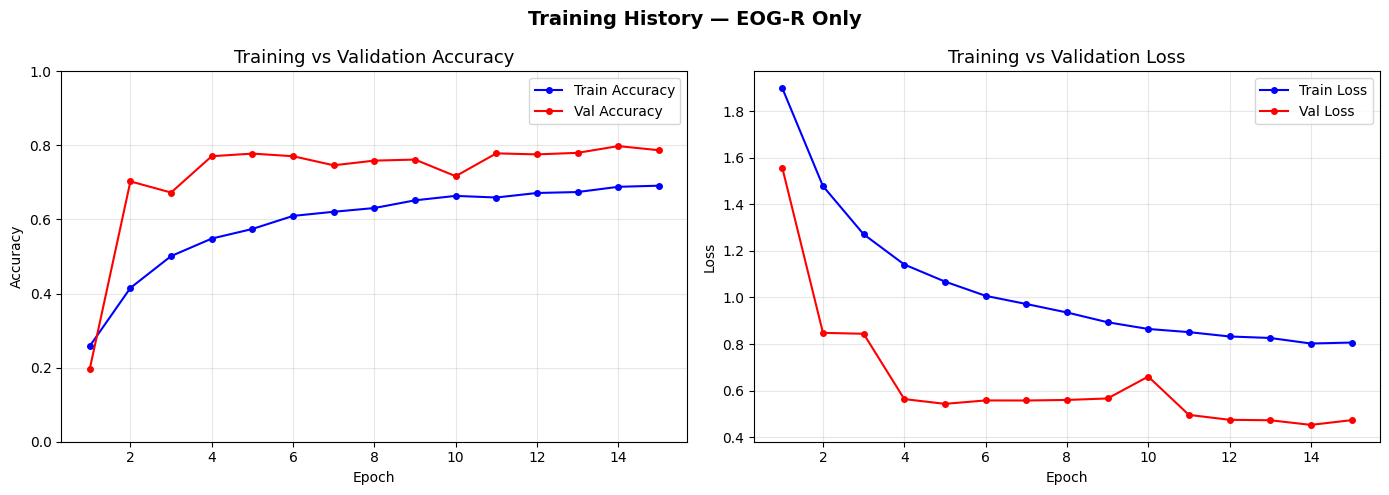


Best Val Accuracy : 0.7982  (Epoch 14)
Final Train Accuracy: 0.6913
Final Val Accuracy  : 0.7870


In [21]:

train_acc  = history.history['accuracy']
val_acc    = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss   = history.history['val_loss']
epochs_range = range(1, len(train_acc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(epochs_range, train_acc, 'b-o', markersize=4, label='Train Accuracy')
ax1.plot(epochs_range, val_acc,   'r-o', markersize=4, label='Val Accuracy')
ax1.set_title('Training vs Validation Accuracy', fontsize=13)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(alpha=0.3)
ax1.set_ylim([0, 1])

# Loss
ax2.plot(epochs_range, train_loss, 'b-o', markersize=4, label='Train Loss')
ax2.plot(epochs_range, val_loss,   'r-o', markersize=4, label='Val Loss')
ax2.set_title('Training vs Validation Loss', fontsize=13)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Training History — EOG-R Only', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nBest Val Accuracy : {max(val_acc):.4f}  (Epoch {np.argmax(val_acc)+1})")
print(f"Final Train Accuracy: {train_acc[-1]:.4f}")
print(f"Final Val Accuracy  : {val_acc[-1]:.4f}")

In [22]:

model = tf.keras.models.load_model("best_model_eogr.keras")
print("✅ Model loaded successfully!")
print(f"Input shape : {model.input_shape}")
print(f"Output shape: {model.output_shape}")

✅ Model loaded successfully!
Input shape : (None, 3000, 1)
Output shape: (None, 5)



── Test Set Evaluation ──
75/75 ━━━━━━━━━━━━━━━━━━━━ 61s 768ms/step
              precision    recall  f1-score   support

        Wake       1.00      0.88      0.94      1335
          N1       0.18      0.59      0.27        92
          N2       0.90      0.71      0.79       637
          N3       0.49      0.80      0.61       112
         REM       0.50      0.50      0.50       222

    accuracy                           0.79      2398
   macro avg       0.61      0.70      0.62      2398
weighted avg       0.87      0.79      0.82      2398



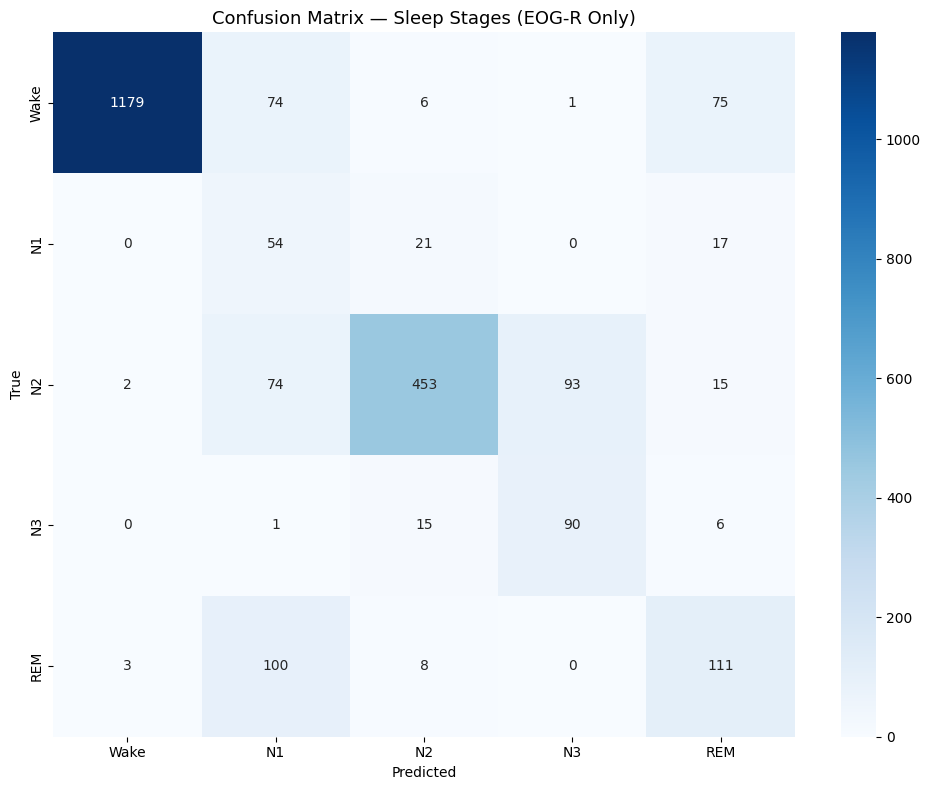

In [23]:
#Evaluate on Test Set
# Classification report + Confusion Matrix
# ────────────────
print("\n── Test Set Evaluation ──")
y_pred_test = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred_test, target_names=CLASS_NAMES))

cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — Sleep Stages (EOG-R Only)', fontsize=13)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

In [24]:
#Evaluate on Validation Set
# ─────────────────────────────────────────────────────────

print("\n── Validation Set Evaluation ──")
y_pred_val = np.argmax(model.predict(X_val), axis=1)
print(classification_report(y_val, y_pred_val,
                             target_names=CLASS_NAMES, zero_division=0))


── Validation Set Evaluation ──
45/45 ━━━━━━━━━━━━━━━━━━━━ 22s 466ms/step
              precision    recall  f1-score   support

        Wake       1.00      0.91      0.95       882
          N1       0.24      0.79      0.37        85
          N2       0.91      0.57      0.70       376
          N3       0.24      0.75      0.36        16
         REM       0.68      0.56      0.61        68

    accuracy                           0.80      1427
   macro avg       0.61      0.72      0.60      1427
weighted avg       0.90      0.80      0.83      1427



75/75 ━━━━━━━━━━━━━━━━━━━━ 31s 398ms/step


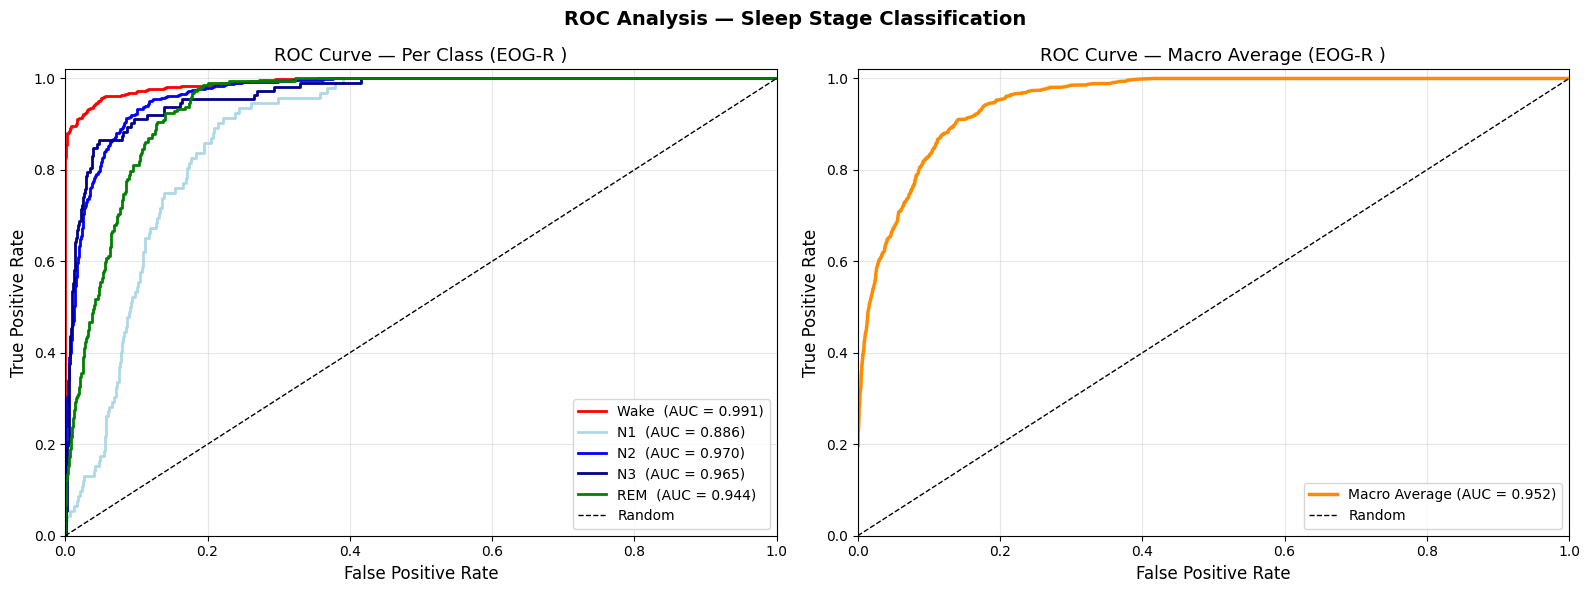


── AUC Scores ──
  Wake : 0.9911
  N1   : 0.8862
  N2   : 0.9697
  N3   : 0.9653
  REM  : 0.9441

  Macro Average: 0.9515


In [26]:
#ROC Curves 

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

n_classes  = len(CLASS_NAMES)

# Binarize labels for One-vs-Rest ROC
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

# Get predicted probabilities
y_prob = model.predict(X_test)    # shape: (N, 5)

# Compute ROC and AUC per class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i]        = auc(fpr[i], tpr[i])

# Macro-average ROC
all_fpr          = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr         = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr    += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr        /= n_classes
fpr["macro"]     = all_fpr
tpr["macro"]     = mean_tpr
roc_auc["macro"] = auc(all_fpr, mean_tpr)

# Plot
colors = ['red', 'lightblue', 'blue', 'darkblue', 'green']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: per-class
ax = axes[0]
for i, (cls, color) in enumerate(zip(CLASS_NAMES, colors)):
    ax.plot(fpr[i], tpr[i], color=color, linewidth=2,
            label=f"{cls}  (AUC = {roc_auc[i]:.3f})")
ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Random')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Per Class (EOG-R )', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

# Right: macro average
ax = axes[1]
ax.plot(fpr["macro"], tpr["macro"], color='darkorange', linewidth=2.5,
        label=f'Macro Average (AUC = {roc_auc["macro"]:.3f})')
ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Random')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Macro Average (EOG-R )', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

plt.suptitle('ROC Analysis — Sleep Stage Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print AUC scores
print("\n── AUC Scores ──")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {cls:5s}: {roc_auc[i]:.4f}")
print(f"\n  Macro Average: {roc_auc['macro']:.4f}")